<a href="https://colab.research.google.com/github/GautamChy/Data-Science-Journey/blob/main/MatplotlibDay03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Matplotlib** is a powerful Python library used for creating visualizations such as line charts, bar graphs, scatter plots, and more. It allows you to represent data visually, making it easier to understand patterns and trends. With its customizable features, you can enhance your plots to suit various presentation needs. It serves as a foundation for learning more advanced data visualization tools in Python.

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt


# LINE GRAPH

# gapminder

In [ ]:
!pip install gapminder

In [ ]:
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')
tips = sns.load_dataset('tips')
mpg = sns.load_dataset('mpg')

from gapminder import gapminder
gap = gapminder.copy()

print(titanic.head())
print(gap.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
       country continent  year  lifeExp       pop   gdpPercap
0  Afghanistan      Asia  1952   28.801   8425333  779.445314
1  Afghanistan      Asia  1957   30.332   9240934  820.853030
2  Afghanistan      Asia  1962   

In [ ]:
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [ ]:
yearly_life_exp = gap.groupby('year')['lifeExp'].mean().reset_index()
yearly_life_exp

,year,lifeExp
0,1952,49.057620
1,1957,51.507401
2,1962,53.609249
3,1967,55.678290
4,1972,57.647386
5,1977,59.570157
6,1982,61.533197
7,1987,63.212613
8,1992,64.160338
9,1997,65.014676


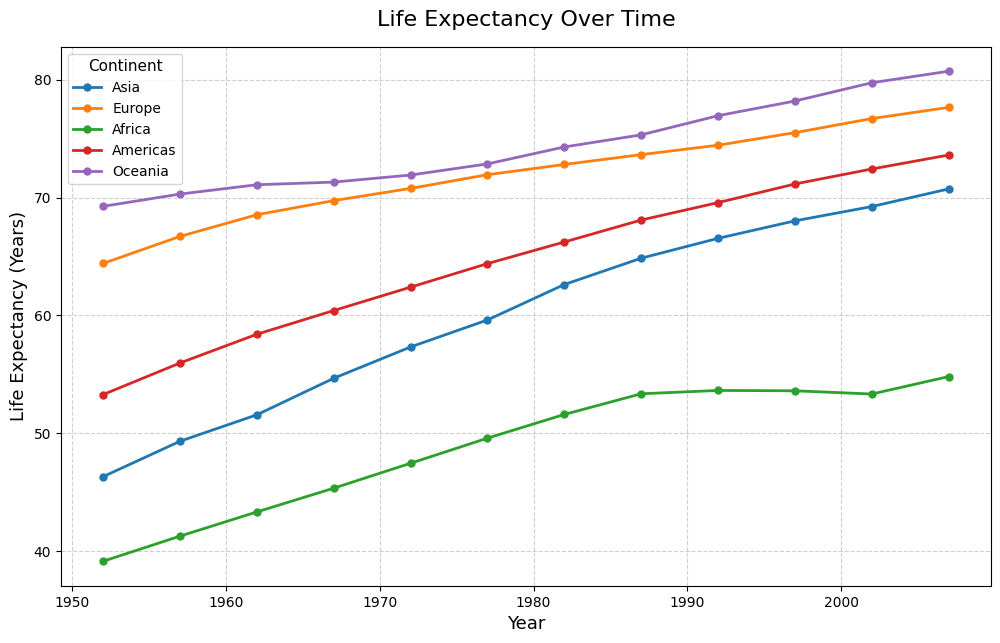

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

# Each continent gets its own line
for continent in gap['continent'].unique():
  data = gap[gap['continent'] == continent]
  data = data.groupby('year')['lifeExp'].mean().reset_index()

  ax.plot(
      data['year'],
      data['lifeExp'],
      marker='o',
      markersize=5,
      linewidth=2,
      label=continent
  )

  ax.set_title('Life Expectancy Over Time', fontsize=16, pad=15)
  ax.set_xlabel('Year', fontsize=13)
  ax.set_ylabel('Life Expectancy (Years)', fontsize=13)
  ax.legend(title='Continent',fontsize=10, title_fontsize=11)  # Asia, Europe, Africa, Americas, Oceania
  ax.grid(True, alpha = 0.6, linestyle='--')

# SCATTER
- ax.scatter

In [ ]:
gap

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


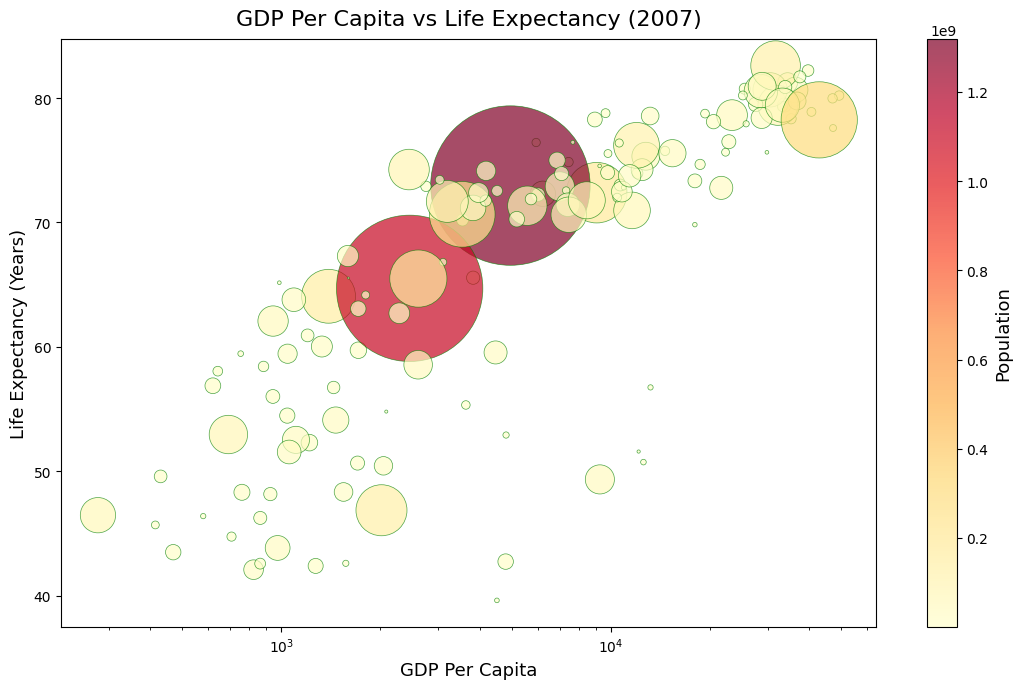

In [ ]:
gap_2007 = gap[gap['year'] == 2007]

fig, ax = plt.subplots(figsize=(11,7))

scatter = ax.scatter(
    gap_2007['gdpPercap'],
    gap_2007['lifeExp'],
    c=gap_2007['pop'],
    cmap='YlOrRd',     # cmap means colouring
    s=gap_2007['pop']/100000,  # s means point ko size, 2007 ko population lai divide garaako 100000
    alpha=0.7, # alpha means transperancy
    edgecolors = 'green',
    linewidths = 0.5
)

cbar = plt.colorbar(scatter, ax = ax)  # ax means axis
cbar.set_label('Population', fontsize = 13)

ax.set_title("GDP Per Capita vs Life Expectancy (2007)", fontsize=16, pad=10)
ax.set_xlabel('GDP Per Capita' , fontsize=13) # # xlabel() define x-axis label
ax.set_ylabel('Life Expectancy (Years)', fontsize=13) # # ylabel() define y-axis label

ax.set_xscale('log')

plt.tight_layout()
plt.show()


In [ ]:
gap

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


# .......................................................................................................................................................................

# BAR

/tmp/ipykernel_767/4198020664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class = titanic.groupby('class')['survived'].mean() * 100


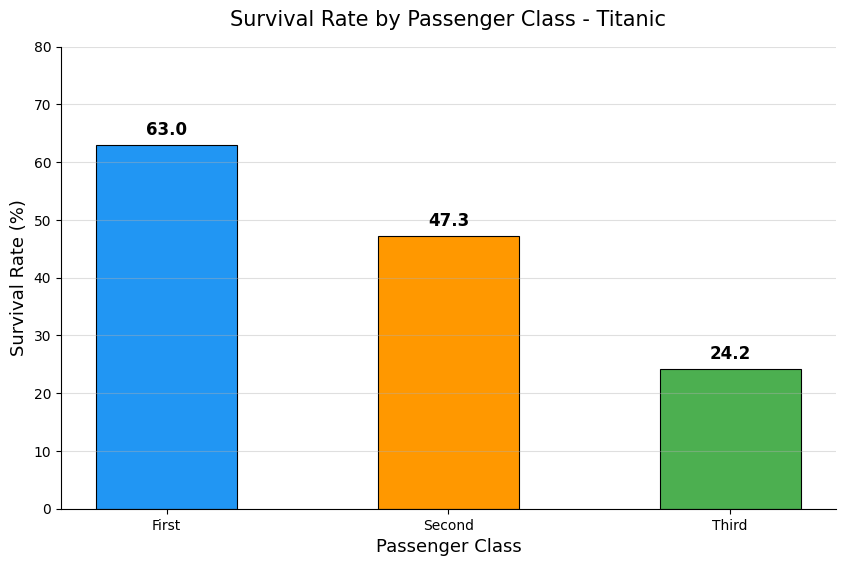

In [ ]:
survival_by_class = titanic.groupby('class')['survived'].mean() * 100

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    survival_by_class.index,
    survival_by_class.values,
    color=['#2196F3','#FF9800','#4CAF50'],
    width = 0.5,
    edgecolor = 'black',
    linewidth = 0.8
)

for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height + 1,
      f'{height:.1f}',
      ha='center', va='bottom',
      fontsize = 12, fontweight = 'bold'
  )

  ax.set_title("Survival Rate by Passenger Class - Titanic", fontsize = 15, pad = 15)
  ax.set_xlabel('Passenger Class', fontsize = 13)
  ax.set_ylabel('Survival Rate (%)', fontsize = 13)
  ax.set_ylim(0, 80)
  ax.grid(axis='y', alpha = 0.4)
  ax.spines[['top','right']].set_visible(False)